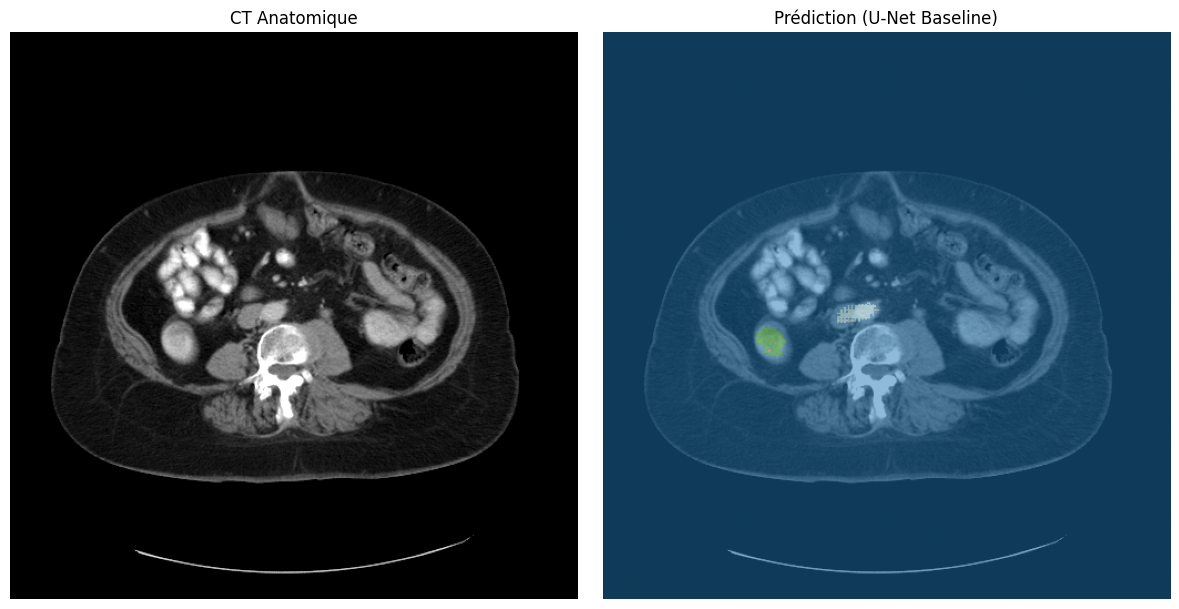

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Chemins (ajuste le nom exact de ton fichier test)
test_img_path = Path("../data/raw/imagesTs/img0062.nii.gz")
pred_path = Path("../predictions/img0062_pred.nii.gz")

img_data = nib.load(test_img_path).get_fdata()
pred_data = nib.load(pred_path).get_fdata()

# Choisir une coupe au milieu de l'axe Z (Axial)
slice_z = img_data.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Afficher le scanner CT brut (avec un windowing grossier pour l'affichage)
img_slice = np.clip(img_data[:, :, slice_z], -150, 250)
axes[0].imshow(img_slice.T, cmap="gray", origin="lower")
axes[0].set_title("CT Anatomique")
axes[0].axis("off")

# Afficher la prédiction superposée
axes[1].imshow(img_slice.T, cmap="gray", origin="lower")
# cmap="tab20" permet de bien séparer les couleurs des 14 classes
axes[1].imshow(pred_data[:, :, slice_z].T, cmap="tab20", alpha=0.5, origin="lower")
axes[1].set_title("Prédiction (U-Net Baseline)")
axes[1].axis("off")

plt.tight_layout()
plt.show()